In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys # Add the module path. Windows and Linux use different path separators; the raw string prevents escape sequences such as \n from being interpreted.
sys.path.append(r"../main_code/2d")
import generate_data,mesh,adaptive_int,visual,matrix_assemble,inverse_solver,mea_2d,net_2d,source_eval,error_general_2d,main
CUDA_LAUNCH_BLOCKING=1

cuda:1


In [2]:
import numpy as np
S_num_store=np.load("./IARFM/noise=10%/S_num_store_10%.npy")


In [3]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-0.3, 0.3, 301)
y = np.linspace(-0.3, 0.3, 301)
X, Y = np.meshgrid(x, y,indexing='ij')
plt.figure(figsize=(8, 6))
S_num_10=S_num_store[-1]

<Figure size 800x600 with 0 Axes>

In [4]:
def ana_S(y):
    y0=y[:,0]
    y1=y[:,1]
    return 1.1*np.exp(-200*((y0-0.01)**2+(y1-0.12)**2))-100*(y1**2-y0**2)*np.exp(-90*(y0**2+y1**2))
XX = np.array([X.ravel(), Y.ravel()]).T
S_true=ana_S(XX).reshape(X.shape)

Plot saved as ./IARFM/noise=10%/ex4.2_S_num_10.pdf


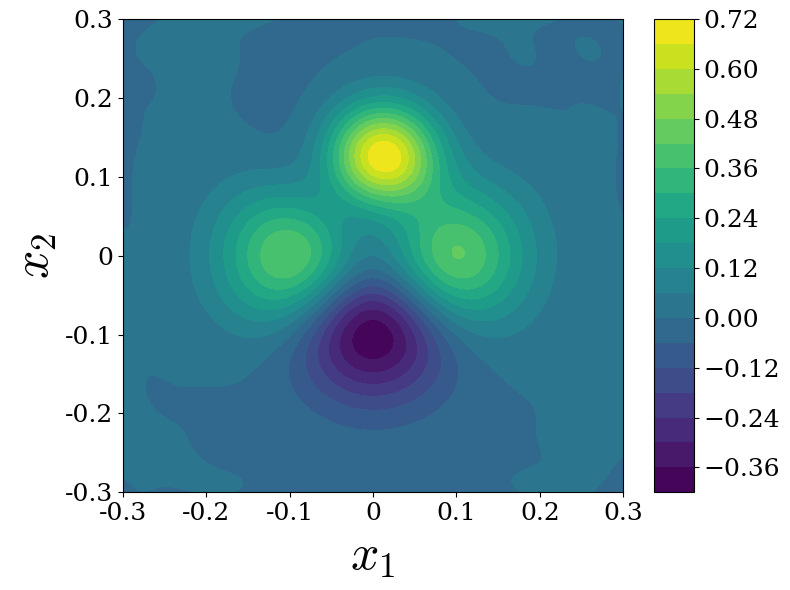

Plot saved as ./IARFM/noise=10%/ex4.2_S_exact.pdf


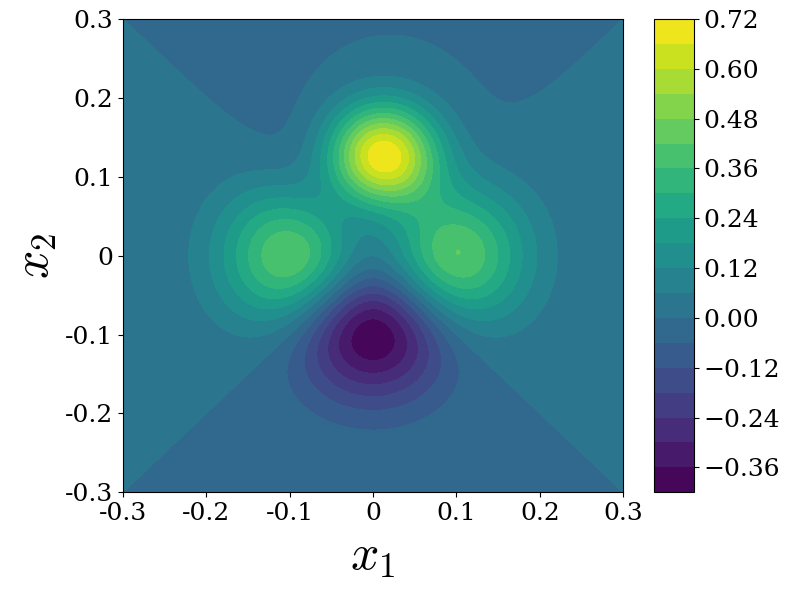

Plot saved as ./IARFM/noise=10%/ex4.2_abs_S.pdf


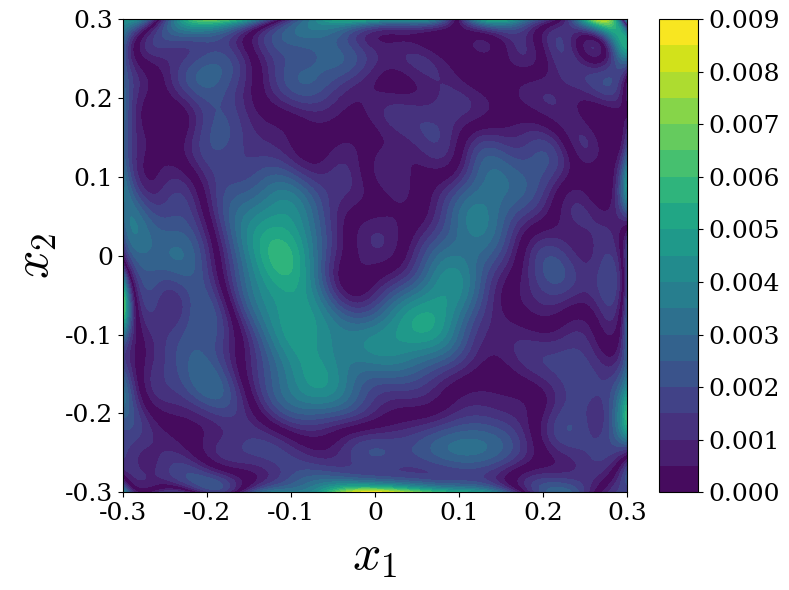

In [5]:
import visual
reload(visual)
visual.draw(X, Y, S_num_10, output_directory="./IARFM/noise=10%/", output_filename="S_num_10.pdf")
visual.draw(X, Y, S_true, output_directory="./IARFM/noise=10%/", output_filename="S_exact.pdf")
visual.draw(X, Y, np.abs(S_num_10 - S_true), output_directory="./IARFM/noise=10%/", output_filename="abs_S.pdf")